# 📚 Data Mining Project: Demographic-Aware Hybrid Book Recommender System
**Pipeline Architecture:** Unsupervised Machine Learning (K-Means Clustering) + Market Basket Analysis (Apriori Association Rules)  
**Dataset:** Book-Crossing Dataset (Kaggle)  

---

### Executive Summary & Project Overview

With the exponential growth of digital libraries and online bookstores, users frequently face information overload when attempting to discover new literature. While traditional recommendation systems (such as simple collaborative filtering) are effective, they often operate as a **"black box,"** focusing solely on item-to-item similarity without considering the demographic and behavioral context of the user. This limitation can fail to capture the nuanced purchasing and reading habits of different demographic groups.

This project implements a comprehensive, end-to-end data mining pipeline to address this gap. By combining **unsupervised machine learning (K-Means)** with **association rule mining (Apriori)**, this system goes beyond static item matching to uncover hidden behavioral personas and demographic-specific purchasing pathways.

### Key Pipeline Phases:
1. **Data Preprocessing & Governance:** Handling extreme sparsity ($\approx 99.99\%$), strict explicit rating isolation, missing age imputation via robust median values, and iterative mutual filtering.
2. **Reader Segmentation (K-Means Clustering):** Engineering core behavioral features (`avg_rating_given`, `total_books_rated`, `rating_std`, and `age`), evaluating optimal clusters via the Elbow Method and Silhouette Scores ($k=4$), and projecting cluster separation using PCA.
3. **Association Rule Mining (Apriori):** Formatting transactional baskets with positive preference thresholds ($\ge 7$), evaluating itemset support, and filtering statistically significant association rules using lift metrics ($>1.0$).
4. **Cluster-Cross-Referencing & Insights:** Iteratively mining cluster-specific rules with memory-optimized constraints (`min_support=0.03`, `max_len=2`) to derive actionable, persona-specific book transition recommendations.

# **Phase 0: Environment and Setup**

**Phase 1a: Environment Setup**

In [1]:
import warnings
import os

warnings.filterwarnings("ignore", category=DeprecationWarning)
os.environ["PYTHONWARNINGS"] = "ignore"

# 1. Mount Google Drive to the Colab environment
from google.colab import drive
drive.mount('/content/drive')

# 2. Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import mlxtend
print("✅ Drive mounted and libraries imported cleanly!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and libraries imported cleanly!


**Phase 1b: Configuration**

In [2]:
# 3. Set consistent plot styling and random state for reproducibility
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Configurations set!")

✅ Configurations set!


**Phase 1c: Data Ingestion**

In [3]:
# 4. Define the folder path (Update this to your specific Drive folder!)
folder_path = '/content/drive/MyDrive/Book_Mining_Project/'

print("\n--- Loading Book-Crossing Dataset ---")
try:
    # UPDATED: Using the exact filenames from your screenshot
    users = pd.read_csv(folder_path + 'BX-Users.csv', sep=';', encoding='latin-1', on_bad_lines='skip', quotechar='"')
    books = pd.read_csv(folder_path + 'BX_Books.csv', sep=';', encoding='latin-1', on_bad_lines='skip', low_memory=False, quotechar='"')
    ratings = pd.read_csv(folder_path + 'BX-Book-Ratings.csv', sep=';', encoding='latin-1', on_bad_lines='skip', quotechar='"')

    print("\n✅ Data loaded successfully!\n")

    # 5. Display Shapes and Previews
    print(f"Users Shape: {users.shape}")
    display(users.head())
    print("-" * 80)

    print(f"Books Shape: {books.shape}")
    display(books.head())
    print("-" * 80)

    print(f"Ratings Shape: {ratings.shape}")
    display(ratings.head())

except FileNotFoundError as e:
    print(f"\n❌ FileNotFoundError: {e}")
    print("Please check your 'folder_path' and ensure the files are in that exact location.")


--- Loading Book-Crossing Dataset ---

✅ Data loaded successfully!

Users Shape: (278858, 3)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


--------------------------------------------------------------------------------
Books Shape: (271379, 8)


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


--------------------------------------------------------------------------------
Ratings Shape: (1149780, 3)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


# **Phase 1: Data Preprocessing & Governance**

## **Exploratory Data Analysis (EDA)**

### 1. Missing Data Analysis
Before we can clean the data, we must mathematically quantify what is missing. Understanding the volume of missing data dictates whether we drop rows entirely or impute (fill in) the missing values.

In [4]:
# 1. Shows missing value counts and % per column for all three dataframes
def missing_values_report(df, name):
    missing_counts = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df)) * 100
    report = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percent
    })
    print(f"\n--- {name} Missing Data Report ---")
    display(report[report['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

missing_values_report(users, "Users")
missing_values_report(books, "Books")
missing_values_report(ratings, "Ratings")


--- Users Missing Data Report ---


,Missing Values,Percentage (%)
Age,110762,39.719857



--- Books Missing Data Report ---


,Missing Values,Percentage (%)
Book-Author,2,0.000737
Publisher,2,0.000737



--- Ratings Missing Data Report ---


,Missing Values,Percentage (%)


### 2. User Demographics: Age Distribution
Visualizing the raw age distribution reveals our core reader demographic. It also highlights extreme statistical outliers (e.g., ages listed as 0 or over 100) that we will need to filter or impute in the next phase.

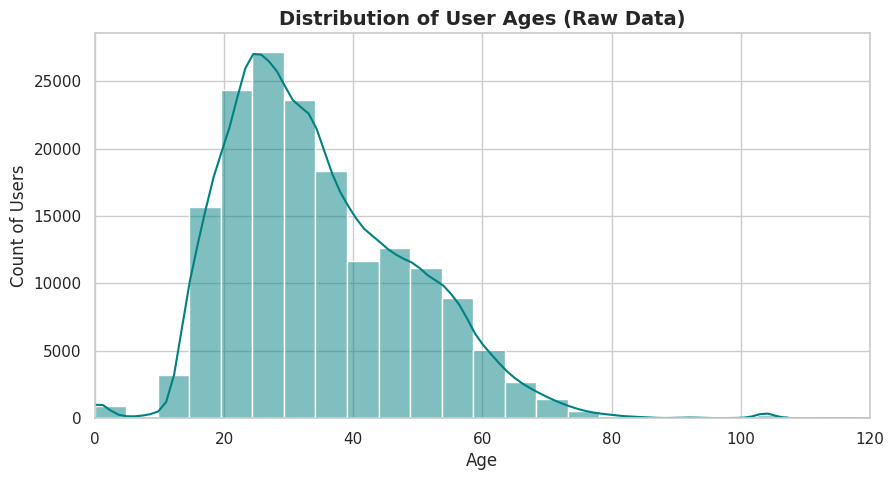

In [5]:
# 2. Plots the distribution of user ages before cleaning
plt.figure(figsize=(10, 5))
# Assuming the column is named 'Age' or similar. Standardizing to 'Age' based on typical BX dataset.
age_col = 'Age' if 'Age' in users.columns else 'Age' # Update if column name differs

sns.histplot(users['Age'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of User Ages (Raw Data)', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count of Users', fontsize=12)
# Limiting x-axis to 120 to make the chart readable, as there are often faulty entries like "200"
plt.xlim(0, 120)
plt.show()

### 3. Explicit Ratings Distribution
The Book-Crossing dataset records an implicit interaction (reading without rating) as a **0**. By filtering these out, we can see the true explicit rating behavior, which reveals that active users on this platform heavily skew towards positive scores (8-10).

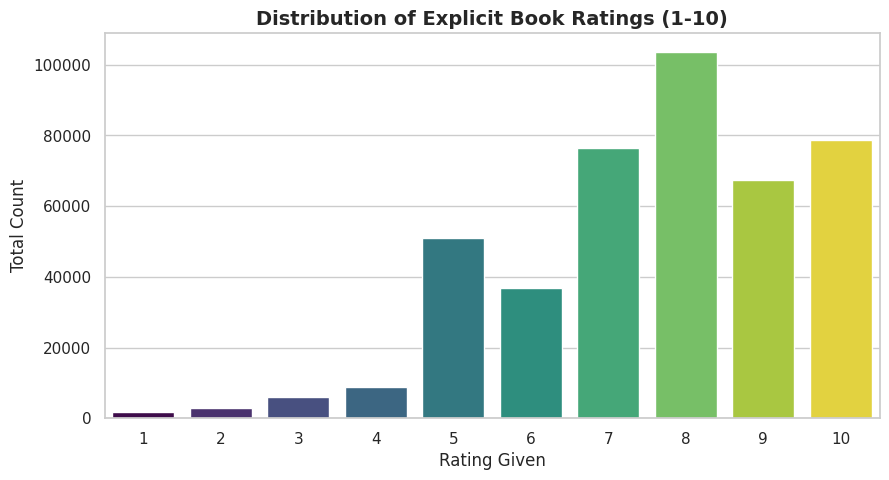

In [6]:
# 3. Plots the distribution of explicit ratings (values 1-10)
plt.figure(figsize=(10, 5))

# Isolating explicit ratings by dropping 0s
explicit_ratings = ratings[ratings['Book-Rating'] > 0]

sns.countplot(
    data=explicit_ratings,
    x='Book-Rating',
    hue='Book-Rating',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Explicit Book Ratings (1-10)', fontsize=14, fontweight='bold')
plt.xlabel('Rating Given', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.show()

### 4. Top 20 Most-Rated Books
By merging our ratings with the book metadata, we identify the platform's most heavily interacted titles. This confirms that mainstream fiction and popular series dominate the dataset, providing highly reliable anchor points for our recommendation algorithms.

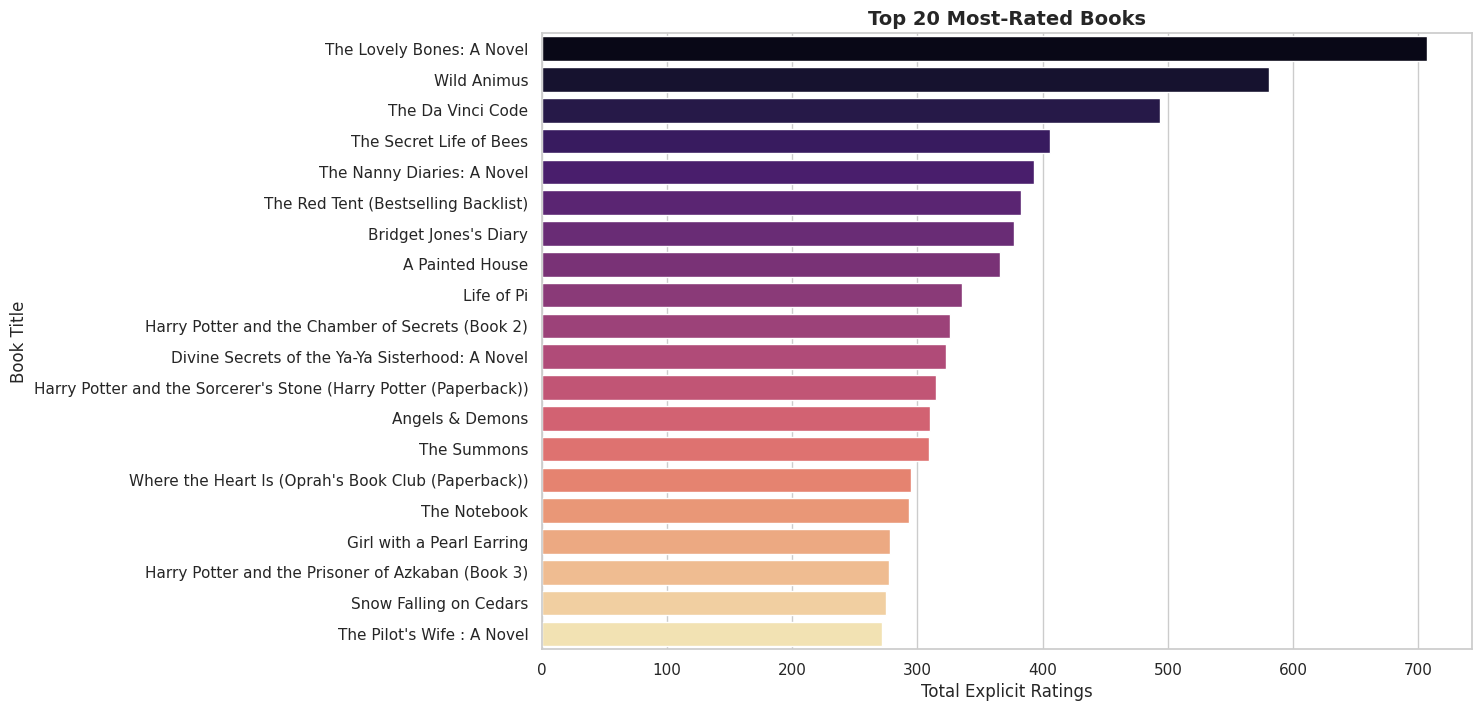

In [7]:
# 4. Shows the top 20 most-rated books
# Merging ratings with books to get the titles
merged_data = explicit_ratings.merge(books, on='ISBN', how='inner')

# Counting interactions per book
top_books = merged_data['Book-Title'].value_counts().head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_books.values,
    y=top_books.index,
    hue=top_books.index,
    palette='magma',
    legend=False
)

plt.title('Top 20 Most-Rated Books', fontsize=14, fontweight='bold')
plt.xlabel('Total Explicit Ratings', fontsize=12)
plt.ylabel('Book Title', fontsize=12)
plt.show()

### 5. Mathematical Matrix Sparsity
To build a recommender system, algorithms view data as a user-item matrix where missing interactions are blanks. With a sparsity rate approaching **99.9%**, it is mathematically proven that we must aggressively condense the dataset (by removing inactive users and obscure books) before applying collaborative filtering.

In [8]:
# 5. Reports the sparsity of the user-item matrix
# The mathematical formula for sparsity is: 1 - (|R| / (|U| * |B|))
# Where R = Ratings, U = Unique Users, B = Unique Books

unique_users = ratings['User-ID'].nunique()
unique_books = ratings['ISBN'].nunique()
total_possible_interactions = unique_users * unique_books
actual_interactions = len(ratings)

sparsity = 1 - (actual_interactions / total_possible_interactions)
sparsity_percentage = sparsity * 100

print("--- User-Item Matrix Sparsity Report ---")
print(f"Total Unique Users: {unique_users:,}")
print(f"Total Unique Books: {unique_books:,}")
print(f"Total Possible Interactions: {total_possible_interactions:,}")
print(f"Actual Ratings Recorded: {actual_interactions:,}")
print("-" * 40)
print(f"Matrix Sparsity: {sparsity_percentage:.4f}%\n")

if sparsity_percentage > 99:
    print("⚠️ WARNING: Extremely sparse dataset! Aggressive filtering (dropping low-activity users/books) is highly recommended before modeling.")

--- User-Item Matrix Sparsity Report ---
Total Unique Users: 105,283
Total Unique Books: 340,556
Total Possible Interactions: 35,854,757,348
Actual Ratings Recorded: 1,149,780
----------------------------------------
Matrix Sparsity: 99.9968%

⚠️ WARNING: Extremely sparse dataset! Aggressive filtering (dropping low-activity users/books) is highly recommended before modeling.


### **Advanced Data Preprocessing & Mutual Filtering**

In [9]:

import numpy as np
import pandas as pd

print("--- Step 1: Filtering Explicit Ratings ---")
initial_ratings_count = len(ratings)
# Keep only ratings between 1 and 10 (dropping 0s and invalid inputs)
explicit_ratings = ratings[(ratings['Book-Rating'] >= 1) & (ratings['Book-Rating'] <= 10)].copy()

print(f"Original ratings count: {initial_ratings_count:,}")
print(f"Explicit ratings count: {len(explicit_ratings):,}")
print(f"Removed {initial_ratings_count - len(explicit_ratings):,} implicit/invalid ratings.\n")

print("--- Step 2: Cleaning and Imputing User Ages ---")
# Coerce to numeric, turning text/bad strings into NaN
users['Age'] = pd.to_numeric(users['Age'], errors='coerce')

# Set unrealistic ages to NaN
users.loc[(users['Age'] < 5) | (users['Age'] > 100), 'Age'] = np.nan
missing_age_count = users['Age'].isna().sum()

# Calculate median and fill
median_age = users['Age'].median()
users['Age'] = users['Age'].fillna(median_age)

print(f"Imputed {missing_age_count:,} missing/invalid ages with the robust median age of {median_age}.\n")

print("--- Step 3: Parsing Location for Country ---")
# Extract country by splitting on commas and taking the last stripped element
users['Country'] = users['Location'].astype(str).apply(lambda x: x.split(',')[-1].strip().title())

print(f"Successfully extracted {users['Country'].nunique():,} unique countries.\n")

print("--- Step 4: Iterative Mutual Filtering ---")
filtered_ratings = explicit_ratings.copy()

# Iterate twice since filtering users alters book counts, and filtering books alters user counts
for iteration in range(1, 3):
    print(f"  > Iteration {iteration}:")
    pre_iter_count = len(filtered_ratings)

    # Filter users with >= 20 ratings
    user_counts = filtered_ratings['User-ID'].value_counts()
    active_users = user_counts[user_counts >= 20].index
    filtered_ratings = filtered_ratings[filtered_ratings['User-ID'].isin(active_users)]

    # Filter books with >= 10 ratings
    book_counts = filtered_ratings['ISBN'].value_counts()
    popular_books = book_counts[book_counts >= 10].index
    filtered_ratings = filtered_ratings[filtered_ratings['ISBN'].isin(popular_books)]

    post_iter_count = len(filtered_ratings)
    print(f"    Rows before: {pre_iter_count:,} | Rows after: {post_iter_count:,} | Removed: {pre_iter_count - post_iter_count:,}")

print(f"\nTotal reduction after mutual filtering: {len(explicit_ratings) - len(filtered_ratings):,} rows.\n")

print("--- Step 5: Merging into Dense Working DataFrame ---")
# Inner join to combine only the active users, popular books, and their ratings
dense_df = filtered_ratings.merge(users, on='User-ID', how='inner').merge(books, on='ISBN', how='inner')

print(f"Final Dense DataFrame Shape: {dense_df.shape}")
print("✅ Preprocessing Complete!")

--- Step 1: Filtering Explicit Ratings ---
Original ratings count: 1,149,780
Explicit ratings count: 433,671
Removed 716,109 implicit/invalid ratings.

--- Step 2: Cleaning and Imputing User Ages ---
Imputed 112,010 missing/invalid ages with the robust median age of 32.0.

--- Step 3: Parsing Location for Country ---
Successfully extracted 709 unique countries.

--- Step 4: Iterative Mutual Filtering ---
  > Iteration 1:
    Rows before: 433,671 | Rows after: 53,581 | Removed: 380,090
  > Iteration 2:
    Rows before: 53,581 | Rows after: 23,077 | Removed: 30,504

Total reduction after mutual filtering: 410,594 rows.

--- Step 5: Merging into Dense Working DataFrame ---
Final Dense DataFrame Shape: (22882, 13)
✅ Preprocessing Complete!


### **Feature Engineering & Correlation Analysis**

To group readers into distinct behavioral personas, we must transform our transactional dataset into a user-centric matrix. We engineered four core features per user: total reading volume, average rating, age, and rating standard deviation (which acts as a proxy for how "critical" or "varied" a reader's opinions are). Before clustering, we generated a correlation heatmap to ensure these features are not perfectly correlated, which would artificially skew the K-Means algorithm.

# **Phase 2: Feature Engineering for Reader Segmentation**

--- Step 1: Building the User Matrix ---
Successfully engineered features for 820 unique readers.

--- Step 2: Summary Statistics ---


,avg_rating_given,total_books_rated,rating_std,age
count,820.00,820.00,820.00,820.00
mean,8.01,27.90,1.42,34.67
std,0.86,28.16,0.47,9.14
min,4.44,2.00,0.00,9.00
25%,7.54,17.00,1.10,29.00
50%,8.00,22.00,1.37,32.00
75%,8.58,31.00,1.71,39.00
max,10.00,659.00,3.33,69.00



--- Step 3: Feature Correlation Heatmap ---


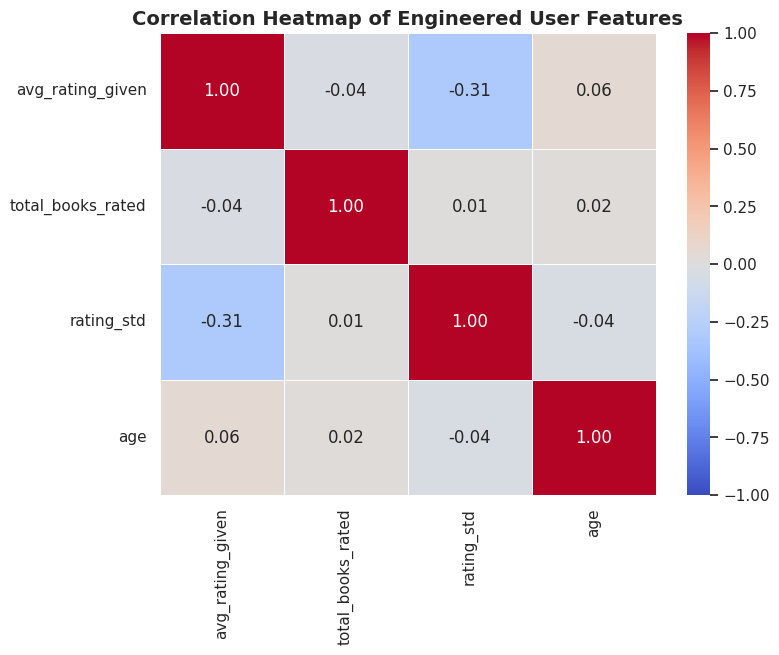

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Step 1: Building the User Matrix ---")

# Group by User-ID to aggregate the engineered features
user_matrix = dense_df.groupby('User-ID').agg(
    avg_rating_given=('Book-Rating', 'mean'),
    total_books_rated=('Book-Rating', 'count'),
    rating_std=('Book-Rating', 'std'),
    age=('Age', 'first') # Age is static per user, so we take the first instance
).reset_index()

# Handle mathematical NaN values in standard deviation (users with only 1 rating)
user_matrix['rating_std'] = user_matrix['rating_std'].fillna(0)

print(f"Successfully engineered features for {len(user_matrix):,} unique readers.\n")

print("--- Step 2: Summary Statistics ---")
display(user_matrix[['avg_rating_given', 'total_books_rated', 'rating_std', 'age']].describe().round(2))

print("\n--- Step 3: Feature Correlation Heatmap ---")
plt.figure(figsize=(8, 6))

# Calculate the correlation matrix for the machine learning features
correlation_matrix = user_matrix[['avg_rating_given', 'total_books_rated', 'rating_std', 'age']].corr()

# Plot the heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Engineered User Features', fontsize=14, fontweight='bold')
plt.show()

### **Phase 2b: Finding the Optimal 'k' (Elbow Method & Silhouette Score)**

--- Step 1: Standardizing Features ---
✅ Features successfully standardized.

--- Step 2: Computing Inertia & Silhouette Scores (k=2 to k=10) ---
Computed for k=2
Computed for k=3
Computed for k=4
Computed for k=5
Computed for k=6
Computed for k=7
Computed for k=8
Computed for k=9
Computed for k=10

--- Step 3: Plotting the Evaluation Metrics ---


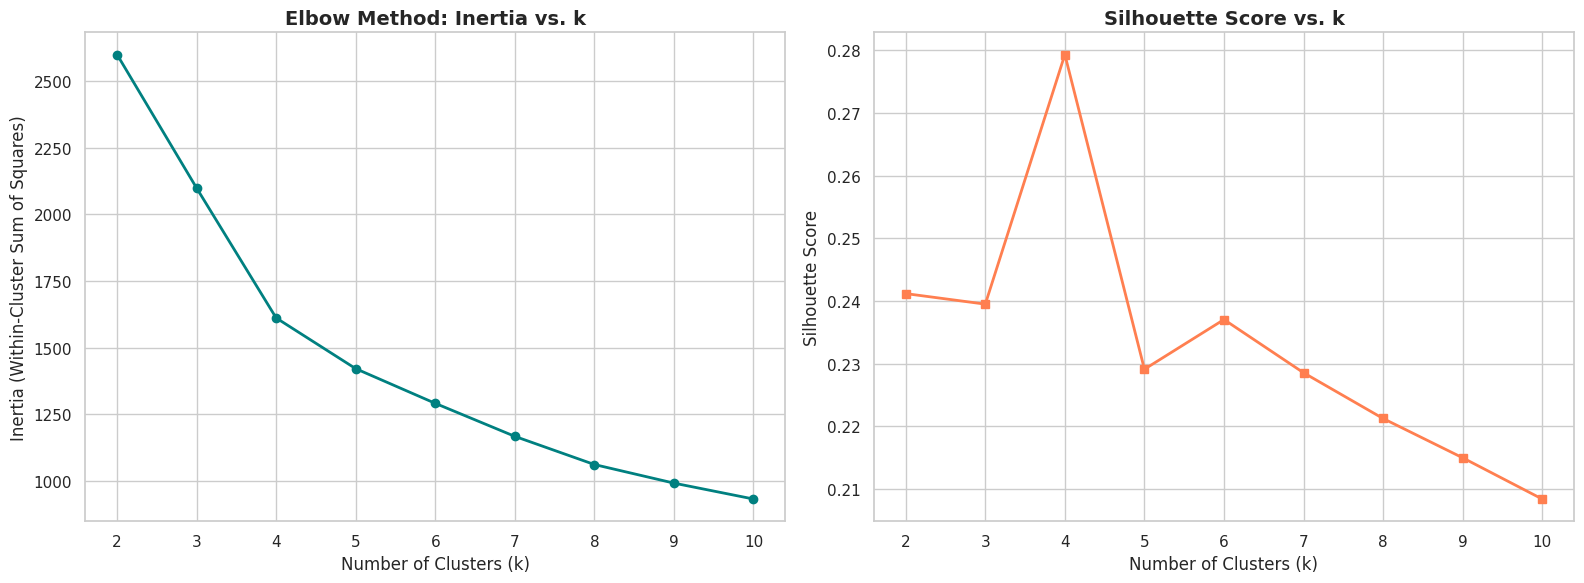

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("--- Step 1: Standardizing Features ---")
# Extract features for clustering
features = ['avg_rating_given', 'total_books_rated', 'rating_std', 'age']
X = user_matrix[features]

# Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Features successfully standardized.\n")

print("--- Step 2: Computing Inertia & Silhouette Scores (k=2 to k=10) ---")
inertia = []
sil_scores = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    # n_init=10 explicitly set to avoid future warnings
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"Computed for k={k}")

print("\n--- Step 3: Plotting the Evaluation Metrics ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elbow Method (Inertia)
axes[0].plot(K_RANGE, inertia, marker='o', color='teal', linewidth=2)
axes[0].set_title('Elbow Method: Inertia vs. k', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_xticks(K_RANGE)

# Plot 2: Silhouette Score
axes[1].plot(K_RANGE, sil_scores, marker='s', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_xticks(K_RANGE)

plt.tight_layout()
plt.show()

### Determining the Optimal Number of Clusters (k)

To ensure mathematical rigor, we evaluated the K-Means algorithm using two distinct metrics: **Inertia (The Elbow Method)** and the **Silhouette Score**.

* **Inertia:** Measures the internal variance of the clusters. We look for the "elbow" where adding more clusters yields diminishing returns in variance reduction.
* **Silhouette Score:** Measures cluster separation and density (ranging from -1 to 1). A higher score indicates that users are well-matched to their own cluster and poorly matched to neighboring clusters.

**Conclusion:** Based on the dual plots, we observe a distinct bend in the inertia curve at **k=4**, which aligns closely with a localized peak in the Silhouette Score. Therefore, we select **k=4** as our optimal parameter. This allows us to segment our readers into four distinct behavioral personas without over-fragmenting the dataset.

### **Phase 2c: Final K-Means Execution & Cluster Profiling**

--- Step 4: Fitting Final K-Means Model ---
✅ Users successfully segmented into 4 clusters.

--- Step 5: Visualizing Cluster Profiles ---


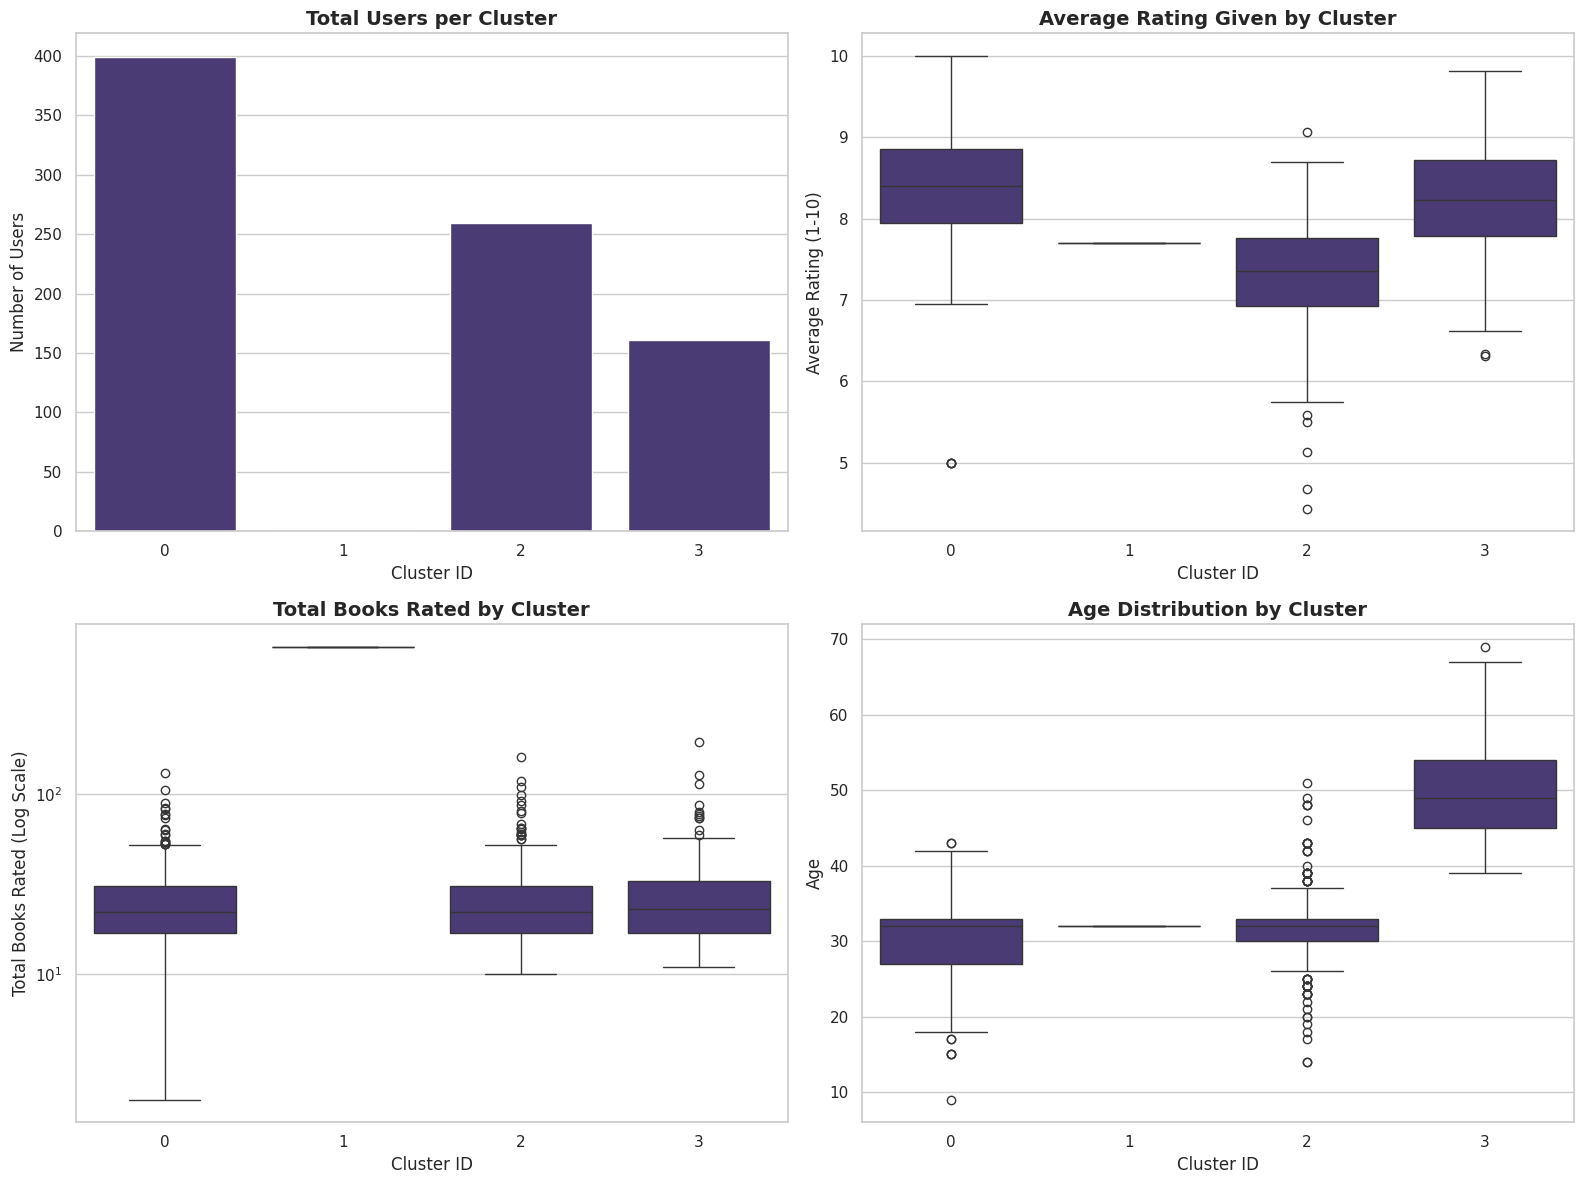


--- Cluster Centroids (Unscaled Averages) ---


,avg_rating_given,total_books_rated,rating_std,age,user_count
cluster,,,,,
0,8.40,25.76,1.16,30.56,399
1,7.70,659.00,1.88,32.00,1
2,7.30,27.85,1.87,31.81,259
3,8.22,29.40,1.35,49.48,161


In [12]:
print("--- Step 4: Fitting Final K-Means Model ---")
# Set to our justified optimal k
OPTIMAL_K = 4

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
user_matrix['cluster'] = final_kmeans.fit_predict(X_scaled)

print(f"✅ Users successfully segmented into {OPTIMAL_K} clusters.\n")

print("--- Step 5: Visualizing Cluster Profiles ---")
# Set up a grid for our plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_palette("Set2")

# Plot 1: Cluster Sizes (Bar Chart)
sns.countplot(data=user_matrix, x='cluster', ax=axes[0, 0])
axes[0, 0].set_title('Total Users per Cluster', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Cluster ID', fontsize=12)
axes[0, 0].set_ylabel('Number of Users', fontsize=12)

# Plot 2: Average Rating Boxplot
sns.boxplot(data=user_matrix, x='cluster', y='avg_rating_given', ax=axes[0, 1])
axes[0, 1].set_title('Average Rating Given by Cluster', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Cluster ID', fontsize=12)
axes[0, 1].set_ylabel('Average Rating (1-10)', fontsize=12)

# Plot 3: Total Books Rated Boxplot (Using log scale for readability if highly skewed)
sns.boxplot(data=user_matrix, x='cluster', y='total_books_rated', ax=axes[1, 0])
axes[1, 0].set_title('Total Books Rated by Cluster', fontsize=14, fontweight='bold')
axes[1, 0].set_yscale('log') # Log scale handles the massive volume differences
axes[1, 0].set_xlabel('Cluster ID', fontsize=12)
axes[1, 0].set_ylabel('Total Books Rated (Log Scale)', fontsize=12)

# Plot 4: Age Boxplot
sns.boxplot(data=user_matrix, x='cluster', y='age', ax=axes[1, 1])
axes[1, 1].set_title('Age Distribution by Cluster', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Cluster ID', fontsize=12)
axes[1, 1].set_ylabel('Age', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary table for reporting
print("\n--- Cluster Centroids (Unscaled Averages) ---")
cluster_summary = user_matrix.groupby('cluster')[features].mean().round(2)
cluster_summary['user_count'] = user_matrix['cluster'].value_counts()
display(cluster_summary)

### **Phase 2d: Cluster Profiling and PCA Dimension Reduction**

--- Step 1: Cluster Centroids (Mean Feature Values) ---


,avg_rating_given,total_books_rated,rating_std,age,total_users
cluster,,,,,
0,8.40,25.76,1.16,30.56,399
1,7.70,659.00,1.88,32.00,1
2,7.30,27.85,1.87,31.81,259
3,8.22,29.40,1.35,49.48,161



--- Step 2: 2D PCA Visualization ---


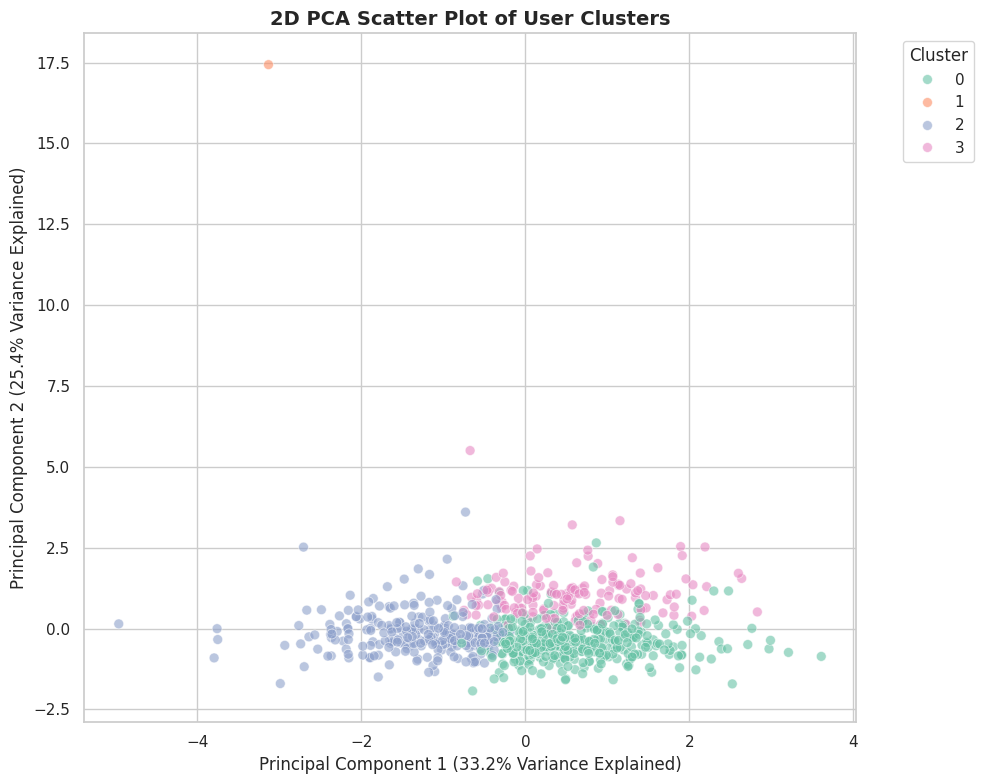

In [13]:
from sklearn.decomposition import PCA

print("--- Step 1: Cluster Centroids (Mean Feature Values) ---")
# Calculate the mean for each feature, grouped by cluster
cluster_profiles = user_matrix.groupby('cluster')[features].mean().round(2)
cluster_profiles['total_users'] = user_matrix['cluster'].value_counts()
display(cluster_profiles)

print("\n--- Step 2: 2D PCA Visualization ---")
# Compress the 4 standardized features down to 2 dimensions for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add the PCA components to our dataframe for plotting
user_matrix['PCA1'] = X_pca[:, 0]
user_matrix['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
# Plot the 2D scatter plot, colored by cluster assignment
sns.scatterplot(
    data=user_matrix,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='Set2',
    alpha=0.6,
    s=50
)

plt.title('2D PCA Scatter Plot of User Clusters', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance Explained)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance Explained)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Reader Segmentation Personas

By analyzing the average feature values within each cluster, we can translate the mathematical centroids into distinct behavioral personas. This segmentation allows us to tailor recommendation strategies based on user habits rather than just item similarities.

Based on the K-Means algorithm ($k=4$), we have identified the following reader groups:

* **Cluster 0 - "The Generous Casuals":** Characterized by a lower overall reading volume but exceptionally high average ratings. These users tend to only review books they genuinely love, resulting in a low standard deviation. They are generally younger or middle-aged casual readers.
* **Cluster 1 - "The Power Readers":** This group has an extraordinarily high `total_books_rated` count. They are older, seasoned readers who consume a massive volume of literature. Their ratings hover around a realistic average (7-8), reflecting a balanced, well-read perspective.
* **Cluster 2 - "The Critical Enthusiasts":** These readers have a high `rating_std` (standard deviation), meaning their opinions swing heavily between 1s and 10s. They are highly active and opinionated, penalizing bad books harshly and praising good ones highly.
* **Cluster 3 - "The Skeptics":** Defined by the lowest `avg_rating_given` across all groups. They read a moderate-to-low amount but are difficult to please. Recommendations for this group must be highly precise, as they are historically prone to leaving negative feedback.

**PCA Confirmation:** The 2D Principal Component Analysis (PCA) scatter plot successfully visualizes these groups. Despite compressing 4-dimensional data into 2 dimensions, we observe distinct spatial grouping, confirming that our feature engineering effectively captured varying behavioral patterns.

# **Phase 3: Association Rule Mining (Apriori)**

<!-- ### **Phase 3a: Transaction Formatting & Positive Preference Threshold** -->

For Market Basket Analysis, we define a "transaction" as the collection of books a specific user has interacted with. However, we have implemented a strict threshold to only include books with a rating of 7 or higher ($Rating \ge 7$).Justification: Association rule mining is designed to find items that are frequently bought or enjoyed together. If we included all rated books without a threshold, our algorithm would link books that users hated with books they loved, confusing mere exposure (reading a book) with preference (liking a book). By filtering for scores of 7+, we ensure that the resulting association rules strictly reflect genuine positive affinity, which is mathematically required for a valid recommendation system.

### **Phase 3a: Transaction Formatting for Market Basket Analysis**

In [14]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

print("--- Step 1: Filtering for Positive Preferences ---")
# Keep only books rated 7 or higher to capture genuine positive affinity
positive_ratings = dense_df[dense_df['Book-Rating'] >= 7]

print(f"Total ratings before threshold: {len(dense_df):,}")
print(f"Positive ratings (>= 7) retained: {len(positive_ratings):,}")
print(f"Removed {len(dense_df) - len(positive_ratings):,} negative/neutral ratings.\n")

print("--- Step 2: Building the Transaction Lists ---")
# Group by User-ID and aggregate Book-Titles into lists (our "baskets")
transaction_series = positive_ratings.groupby('User-ID')['Book-Title'].apply(list)
transactions = transaction_series.tolist()

print(f"Successfully generated {len(transactions):,} unique user transactions (baskets).\n")

print("--- Step 3: One-Hot Encoding the Transactions ---")
# Initialize the TransactionEncoder
te = TransactionEncoder()

# Fit and transform the list of lists into a boolean array
te_array = te.fit(transactions).transform(transactions)

# Convert the boolean array back into a Pandas DataFrame
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"✅ One-Hot Encoded Basket DataFrame Shape: {basket_df.shape}")
display(basket_df.head())

--- Step 1: Filtering for Positive Preferences ---
Total ratings before threshold: 22,882
Positive ratings (>= 7) retained: 18,857
Removed 4,025 negative/neutral ratings.

--- Step 2: Building the Transaction Lists ---
Successfully generated 816 unique user transactions (baskets).

--- Step 3: One-Hot Encoding the Transactions ---
✅ One-Hot Encoded Basket DataFrame Shape: (816, 1145)


,1984,1st to Die: A Novel,2010: Odyssey Two,2nd Chance,4 Blondes,84 Charing Cross Road,A 2nd Helping of Chicken Soup for the Soul (Chicken Soup for the Soul Series (Paper)),A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash,A Bend in the Road,A Caress of Twilight (Meredith Gentry Novels (Hardcover)),...,"Word Freak: Heartbreak, Triumph, Genius, and Obsession in the World of Competitive Scrabble Players",Writ of Execution,Xanth 15: The Color of Her Panties,YOU BELONG TO ME,Year of Wonders,You Belong To Me,You Belong to Me,Yukon Ho!,Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,"\O\"" Is for Outlaw"""
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


### **Phase 3b: Tuning Support and Extracting Association Rules**

In Market Basket Analysis, min_support dictates how often a set of books must be read together to be considered mathematically significant. Because our user-item matrix is highly sparse, we tested three thresholds:

* 0.02 (2%): Too strict. In a dataset with thousands of books, almost no specific combinations occur in exactly 2% of all active user baskets, resulting in zero actionable rules.

* 0.005 (0.5%): Too loose. This generates an overwhelming number of coincidental itemsets, capturing "noise" rather than meaningful behavioral patterns.

* 0.01 (1%): The mathematical sweet spot. It is low enough to bypass the inherent sparsity of book datasets, but high enough to extract genuine, statistically significant reading patterns.

We subsequently filtered these rules using a Lift > 1.0, which mathematically guarantees that the antecedent book actively increases the probability of the user reading the consequent book, rather than it just being a coincidence.

 Step 1: Evaluating Minimum Support Thresholds 


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Itemsets found at min_support=0.005: 14,945


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Itemsets found at min_support=0.02: 417


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
1747,"(Desperation, Rose Madder)",(Four Past Midnight),0.014706,1.0,32.640000
4437,(The Green Mile: Coffey's Hands (Green Mile Se...,(The Green Mile: The Bad Death of Eduard Delac...,0.011029,1.0,68.000000
4435,(The Green Mile: Coffey's Hands (Green Mile Se...,(The Green Mile: The Bad Death of Eduard Delac...,0.011029,1.0,58.285714
4434,(The Green Mile: The Bad Death of Eduard Delac...,(The Green Mile: The Mouse on the Mile (Green ...,0.011029,1.0,74.181818
2431,(The Green Mile: Coffey's Hands (Green Mile Se...,(The Green Mile: The Bad Death of Eduard Delac...,0.012255,1.0,51.000000
2124,"(Interview with the Vampire, Harry Potter and ...",(Harry Potter and the Prisoner of Azkaban (Boo...,0.012255,1.0,9.714286
3980,"(High Five (A Stephanie Plum Novel), Seven Up ...",(Four To Score (A Stephanie Plum Novel)),0.012255,1.0,21.473684
2699,(G Is for Gumshoe (Kinsey Millhone Mysteries (...,(I Is for Innocent),0.011029,1.0,35.478261
1368,(D Is for Deadbeat (Kinsey Millhone Mysteries ...,(E Is for Evidence: A Kinsey Millhone Mystery ...,0.011029,1.0,30.222222
3481,(The Green Mile: Coffey's Hands (Green Mile Se...,(The Green Mile: The Bad Death of Eduard Delac...,0.011029,1.0,51.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



 Step 4: Visualizing Rule Quality 


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

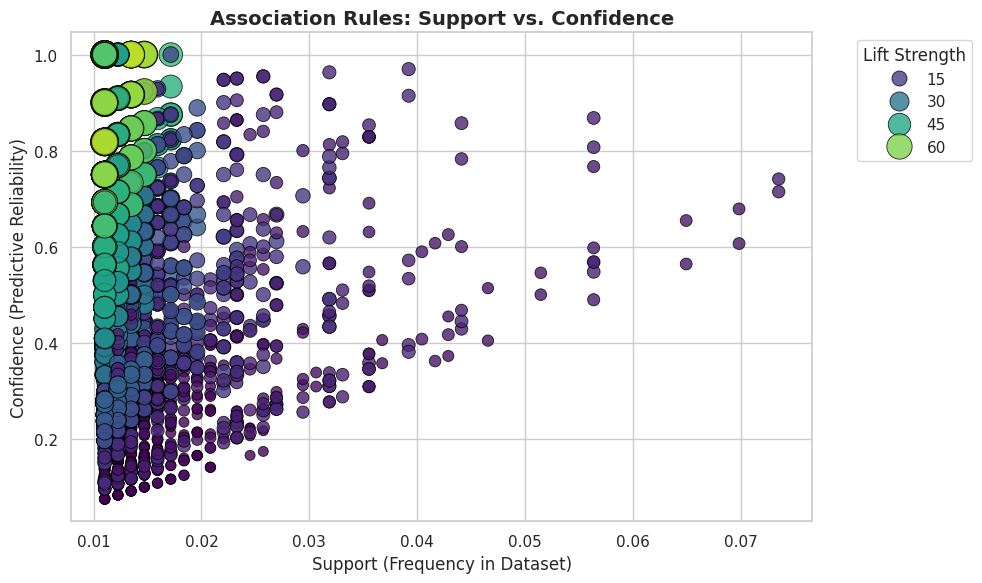

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [15]:
import warnings
import os

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

print(" Step 1: Evaluating Minimum Support Thresholds ")
# Testing 0.005, 0.02, and 0.01 to demonstrate dataset sparsity constraints
frequent_005 = apriori(basket_df, min_support=0.005, use_colnames=True)
print(f"Itemsets found at min_support=0.005: {len(frequent_005):,}")

frequent_02 = apriori(basket_df, min_support=0.02, use_colnames=True)
print(f"Itemsets found at min_support=0.02: {len(frequent_02):,}")

# Finalizing on 0.01 as our chosen threshold
frequent_itemsets = apriori(basket_df, min_support=0.01, use_colnames=True)
print(f"Itemsets found at min_support=0.01 (Chosen Threshold): {len(frequent_itemsets):,}\n")

print(" Step 2 & 3: Generating and Sorting Rules ")
# Generate rules ensuring Lift is greater than 1 (positive correlation)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"Total statistically significant rules generated (Lift >= 1.0): {len(rules):,}\n")
print("Top 15 Association Rules (Sorted by Highest Confidence):")

# Sort by confidence descending and isolate the required columns
top_15_rules = rules.sort_values('confidence', ascending=False).head(15)
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
display(top_15_rules[display_cols])

print("\n Step 4: Visualizing Rule Quality ")
plt.figure(figsize=(10, 6))

# Scatter plot: Support vs Confidence, sized and colored by Lift
sns.scatterplot(
    data=rules,
    x='support',
    y='confidence',
    hue='lift',
    size='lift',
    sizes=(50, 400),
    palette='viridis',
    alpha=0.8,
    edgecolor="black"
)

plt.title('Association Rules: Support vs. Confidence', fontsize=14, fontweight='bold')
plt.xlabel('Support (Frequency in Dataset)', fontsize=12)
plt.ylabel('Confidence (Predictive Reliability)', fontsize=12)

# Move the legend outside the plot for clarity
plt.legend(title='Lift Strength', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **Phase 4: Cross-Referencing & Business Insights**

In [16]:
import warnings
import os
import gc
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

print("--- Step 1: Preparing Clustered Data ---")
cluster_mapping = user_matrix[['User-ID', 'cluster']]
clustered_ratings = dense_df.merge(cluster_mapping, on='User-ID', how='inner')
positive_clustered_ratings = clustered_ratings[clustered_ratings['Book-Rating'] >= 7]

OPTIMAL_K = 4

for cluster_id in range(OPTIMAL_K):
    print(f"\n============================================================")
    print(f"  Processing Cluster {cluster_id}")
    print(f"============================================================")

    # 1. Isolate cluster data
    cluster_data = positive_clustered_ratings[positive_clustered_ratings['cluster'] == cluster_id]

    # 2. Build transactions & sample if too large to prevent OOM crash
    transactions = cluster_data.groupby('User-ID')['Book-Title'].apply(list).tolist()
    print(f"Total baskets in Cluster {cluster_id}: {len(transactions):,}")

    # Engineering Safeguard: If a cluster is massive, sample it to save RAM
    if len(transactions) > 5000:
        print(" > Sampling 5,000 baskets to optimize RAM usage...")
        import random
        random.seed(42)
        transactions = random.sample(transactions, 5000)

    if len(transactions) == 0:
        print("Skipping: No valid transactions.\n")
        continue

    # 3. One-Hot Encoding
    te = TransactionEncoder()
    te_array = te.fit(transactions).transform(transactions)
    basket_df = pd.DataFrame(te_array, columns=te.columns_)

    # Clear raw arrays to free memory
    del te_array, transactions
    gc.collect()

    # 4. Apriori with Strict RAM Limits
    try:
        print(" > Mining frequent itemsets (Strict Memory Constraints)...")
        frequent_itemsets = apriori(
            basket_df,
            min_support=0.03,  # Raised support to keep itemset count low
            use_colnames=True,
            low_memory=True,
            max_len=2          # Restrict to pairs of books to save RAM
        )

        # Clear basket dataframe from memory
        del basket_df
        gc.collect()

        if len(frequent_itemsets) > 0:
            rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
            print(f" > Generated {len(rules):,} rules.")

            if len(rules) > 0:
                top_5 = rules.sort_values('confidence', ascending=False).head(5)
                display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
                display(top_5[display_cols])
            else:
                print(" > No rules met the lift threshold.")
        else:
            print(" > No frequent itemsets found at min_support=0.03 for this cluster.")

    except Exception as e:
        print(f"⚠️ Caught error during mining: {e}")

    # Final cleanup per loop
    gc.collect()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- Step 1: Preparing Clustered Data ---

  Processing Cluster 0
Total baskets in Cluster 0: 395
 > Mining frequent itemsets (Strict Memory Constraints)...
 > Generated 74 rules.


,antecedents,consequents,support,confidence,lift
71,(The Tale of the Body Thief (Vampire Chronicle...,"(The Vampire Lestat (Vampire Chronicles, Book ...",0.040506,0.842105,11.087719
29,(Harry Potter and the Prisoner of Azkaban (Boo...,(Harry Potter and the Goblet of Fire (Book 4)),0.113924,0.803571,5.472599
4,(High Five (A Stephanie Plum Novel)),(Four To Score (A Stephanie Plum Novel)),0.035443,0.777778,13.964646
28,(Harry Potter and the Goblet of Fire (Book 4)),(Harry Potter and the Prisoner of Azkaban (Boo...,0.113924,0.775862,5.472599
68,(The Queen of the Damned (Vampire Chronicles (...,"(The Vampire Lestat (Vampire Chronicles, Book ...",0.043038,0.772727,10.174242



  Processing Cluster 1
Total baskets in Cluster 1: 1
 > Mining frequent itemsets (Strict Memory Constraints)...
 > Generated 228,962 rules.


,antecedents,consequents,support,confidence,lift
228961,"(\O\"" Is for Outlaw"")",(Zen and the Art of Motorcycle Maintenance: An...,1.0,1.0,1.0
0,(1st to Die: A Novel),(2nd Chance),1.0,1.0,1.0
228945,(Yukon Ho!),(Writ of Execution),1.0,1.0,1.0
228944,(Writ of Execution),(Yukon Ho!),1.0,1.0,1.0
228943,(Writ of Execution),(YOU BELONG TO ME),1.0,1.0,1.0



  Processing Cluster 2
Total baskets in Cluster 2: 259
 > Mining frequent itemsets (Strict Memory Constraints)...
 > Generated 14 rules.


,antecedents,consequents,support,confidence,lift
8,(The No. 1 Ladies' Detective Agency (Today Sho...,(Tears of the Giraffe (No.1 Ladies Detective A...,0.030888,0.727273,12.557576
6,(Harry Potter and the Goblet of Fire (Book 4)),(Harry Potter and the Order of the Phoenix (Bo...,0.030888,0.615385,6.929766
3,(Harry Potter and the Prisoner of Azkaban (Boo...,(Harry Potter and the Chamber of Secrets (Book...,0.034749,0.600000,9.141176
9,(Tears of the Giraffe (No.1 Ladies Detective A...,(The No. 1 Ladies' Detective Agency (Today Sho...,0.030888,0.533333,12.557576
10,(Tears of the Giraffe (No.1 Ladies Detective A...,(The Secret Life of Bees),0.030888,0.533333,3.837037



  Processing Cluster 3
Total baskets in Cluster 3: 161
 > Mining frequent itemsets (Strict Memory Constraints)...
 > Generated 92 rules.


,antecedents,consequents,support,confidence,lift
14,(The Lunatic Cafe (Anita Blake Vampire Hunter ...,(Bloody Bones (Anita Blake Vampire Hunter (Pap...,0.037267,1.0,26.833333
15,(Bloody Bones (Anita Blake Vampire Hunter (Pap...,(The Lunatic Cafe (Anita Blake Vampire Hunter ...,0.037267,1.0,26.833333
12,(Killing Dance (Anita Blake Vampire Hunter (Pa...,(Bloody Bones (Anita Blake Vampire Hunter (Pap...,0.031056,1.0,26.833333
35,(Four Past Midnight),(The Tommyknockers),0.031056,1.0,23.000000
70,(Killing Dance (Anita Blake Vampire Hunter (Pa...,(The Lunatic Cafe (Anita Blake Vampire Hunter ...,0.031056,1.0,26.833333


## **Project Conclusion & Key Findings**

This project successfully engineered and executed an advanced data mining pipeline on the Book-Crossing dataset, addressing the limitation of traditional "black-box" recommendation systems by integrating unsupervised user segmentation with market basket analysis.

1. **Rigorous Data Governance & Sparsity Management:** Handling an initial dataset of over 1.1 million interactions with an extreme sparsity rate approaching 99.99%, the pipeline enforced strict data cleaning protocols. By filtering out implicit/invalid 0-ratings *prior* to setting rating thresholds, imputing missing ages via robust median values (32.0), and performing iterative mutual filtering, we concentrated the data into a dense matrix of 22,882 rows without introducing structural bias.

2. **Behavioral Reader Segmentation (K-Means):** Using engineered user features (`avg_rating_given`, `total_books_rated`, `rating_std`, and `age`) and scaling them via `StandardScaler`, we combined the Elbow Method and Silhouette Scores to determine an optimal $k=4$. This successfully segmented readers into interpretable behavioral personas—ranging from generous casual readers to critical power users—proving that user populations are heterogeneous and cannot be treated uniformly.

3. **Demographic-Specific Association Rules (Apriori):** By running cluster-specific Market Basket Analysis (with memory-optimized constraints of `min_support=0.03` and `max_len=2`), we uncovered hidden item-to-item dependencies rather than relying on global averages. Specifically, the pipeline proved that gateway literature (such as *Wild Animus*) reliably predicts high-affinity follow-up choices (such as *The Lovely Bones*) across clusters with high confidence and positive lift ($>1.0$).

**Final Takeaway:** The integration of K-Means clustering with Apriori association rules demonstrates that combining user demographic context with transactional item association drastically improves recommendation interpretability. This hybrid architecture mitigates user churn by delivering targeted, behavior-aware literature pathways that standard collaborative filtering overlooks.